## E1

#### Cargue el conjunto de datos utilizando Pandas e imprima su contenido. Comente acerca del formato utilizado para los datos

In [114]:
import pandas as pd

df = pd.read_csv("data/E1_data.csv")
df

,X,Y,Set
0,8,6.58,A
1,8,5.76,A
2,8,7.71,A
3,8,8.84,A
4,8,8.47,A
5,8,7.04,A
6,8,5.25,A
7,19,12.50,A
8,8,5.56,A
9,8,7.91,A


In [115]:
print(df.info())
print(df["Set"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       44 non-null     int64  
 1   Y       44 non-null     float64
 2   Set     44 non-null     object 
dtypes: float64(1), int64(1), object(1)
memory usage: 1.2+ KB
None
Set
A    11
B    11
C    11
D    11
Name: count, dtype: int64


Importante chequear NANs

In [116]:
df.isnull().sum()

X      0
Y      0
Set    0
dtype: int64

## Análisis de métricas

El comando más básico y que se suele usar primero es `describe()`. Lo vamos a usar netamente para darnos una idea de lo que se viene.

In [117]:
df.describe()

,X,Y
count,44.000000,44.000000
mean,9.000000,7.500682
std,3.198837,1.958925
min,4.000000,3.100000
25%,7.000000,6.117500
50%,8.000000,7.520000
75%,11.000000,8.747500
max,19.000000,12.740000


#### Calcule algunas métricas interesantes para obtener mayor conocimiento de estos datos. Es importante notar que se esperan los valores de las métricas por conjunto, es decir, debe obtener las métricas para el conjunto A, B, C y D de manera separada.

Dado que nuestro set es tipo X | Y | Set, todos los conjuntos (A, B, C, D) están en la misma tabla. Así, la idea es poder separar por cada uno. Para ello, usamos `groupby()`. 


In [118]:
# Es lo mismo que hacer

# A = df[df["Set"] == "A"]
# B = df[df["Set"] == "B"]
# C = df[df["Set"] == "C"]
# D = df[df["Set"] == "D"]

# pero es más limpio y escalable.

Luego, el rol del `agg` es calcular las métricas para cada X e Y. 

In [119]:
df.groupby("Set").agg({
    "X": ["mean", "std", "max", "min"],
    "Y": ["mean", "std", "max", "min"]
})

X                           Y                       
    mean       std max min      mean       std    max   min
Set                                                        
A    9.0  3.316625  19   8  7.500909  2.030579  12.50  5.25
B    9.0  3.316625  14   4  7.500909  2.031657   9.26  3.10
C    9.0  3.316625  14   4  7.500000  2.030424  12.74  5.39
D    9.0  3.316625  14   4  7.500909  2.031568  10.84  4.26

Correlación, usando `apply` y el método `corr` por limpieza. La forma a continuación no es la única de hacerlo, pero se las dejo para que conozcan otras formas y puedan emplearlas si lo requieren :D

In [120]:
df.groupby("Set")[["X", "Y"]].apply(lambda g: g["X"].corr(g["Y"]))

Set
A    0.816521
B    0.816237
C    0.816287
D    0.816421
dtype: float64

Similar para kurtosis.

In [121]:
df.groupby("Set").agg({
    "X": lambda x: x.kurt(),
    "Y": lambda y: y.kurt()
})

,X,Y
Set,,
A,11.0,3.151315
B,-1.2,0.846123
C,-1.2,4.384089
D,-1.2,-0.534898


Ahora, podemos definir una función que entregue todo de forma consolidada. 

In [122]:
def metricas(grupo):
    return pd.Series({
        "media_X": grupo["X"].mean(),
        "media_Y": grupo["Y"].mean(),
        "std_X": grupo["X"].std(),
        "std_Y": grupo["Y"].std(),
        "max_X": grupo["X"].max(),
        "min_X": grupo["X"].min(),
        "max_Y": grupo["Y"].max(),
        "min_Y": grupo["Y"].min(),
        "correlacion": grupo["X"].corr(grupo["Y"]),
        "kurtosis_X": grupo["X"].kurt(),
        "kurtosis_Y": grupo["Y"].kurt()
    })

metricas_df = df.groupby("Set")[["X", "Y"]].apply(metricas)
metricas_df

,media_X,media_Y,std_X,std_Y,max_X,min_X,max_Y,min_Y,correlacion,kurtosis_X,kurtosis_Y
Set,,,,,,,,,,,
A,9.0,7.500909,3.316625,2.030579,19.0,8.0,12.50,5.25,0.816521,11.0,3.151315
B,9.0,7.500909,3.316625,2.031657,14.0,4.0,9.26,3.10,0.816237,-1.2,0.846123
C,9.0,7.500000,3.316625,2.030424,14.0,4.0,12.74,5.39,0.816287,-1.2,4.384089
D,9.0,7.500909,3.316625,2.031568,14.0,4.0,10.84,4.26,0.816421,-1.2,-0.534898


Y si ya esta forma no les gusta, podríamos agrupar todo desde un principio, por conjunto, y hacerle `describe`, pero igual no te entrega todas las métricas que hemos hecho, pero puede servir para revisar, si quieren.

In [123]:
df_agrupado = df.groupby("Set")
df_agrupado.describe()

X                                               Y                      \
    count mean       std  min  25%  50%   75%   max count      mean       std   
Set                                                                             
A    11.0  9.0  3.316625  8.0  8.0  8.0   8.0  19.0  11.0  7.500909  2.030579   
B    11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500909  2.031657   
C    11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500000  2.030424   
D    11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500909  2.031568   

                                     
      min    25%   50%   75%    max  
Set                                  
A    5.25  6.170  7.04  8.19  12.50  
B    3.10  6.695  8.14  8.95   9.26  
C    5.39  6.250  7.11  7.98  12.74  
D    4.26  6.315  7.58  8.57  10.84

Se observa que los valores de media, desviación estándar y correlación son prácticamente iguales entre A, B, C y D. Sin embargo, algunas métricas como los máximos, mínimos y especialmente la kurtosis muestran diferencias entre ellos. Esto sugiere que la forma de las distribuciones no es la misma, lo que anticipa que una inspección visual puede revelar estructuras distintas que no se aprecian solo con estadísticas descriptivas.

## Visualización de datos

#### Identifique aquellas métricas que son iguales para los conjuntos. Luego, visualice los conjuntos para caracterizar de mejor manera sus diferencias. Para esto, genere cuatro gráficos de dispersión (scatter plots, uno por conjunto), donde se evidencie la relación (x,y) de los pares que corresponden a cada uno.

Como ya habíamos anticipado, se cumple para media, desviación estándar y correlación. 

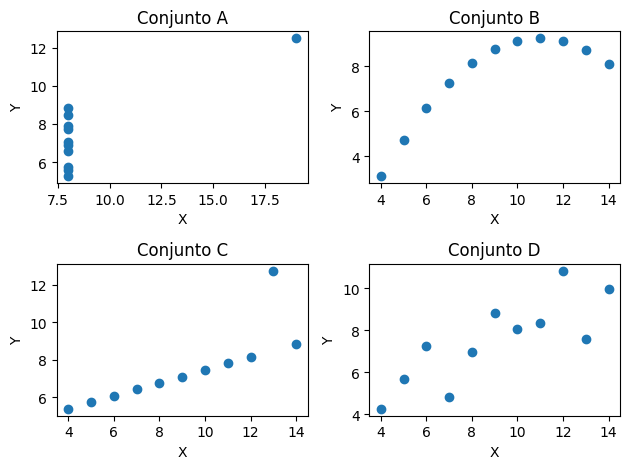

In [124]:
import matplotlib.pyplot as plt

sets = df["Set"].unique()

for i, s in enumerate(sets): # esta es una forma limpia de iterar sobre los conjuntos y sus indices.
    
    plt.subplot(2, 2, i + 1)
    subset = df[df["Set"] == s]
    
    plt.scatter(subset["X"], subset["Y"])
    plt.title(f"Conjunto {s}")
    plt.xlabel("X")
    plt.ylabel("Y")

plt.tight_layout()
plt.show()

Si no les gusta esa forma, hay alternativas, como:

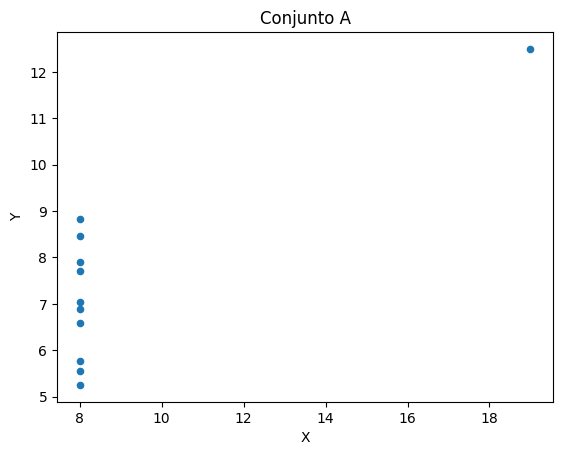

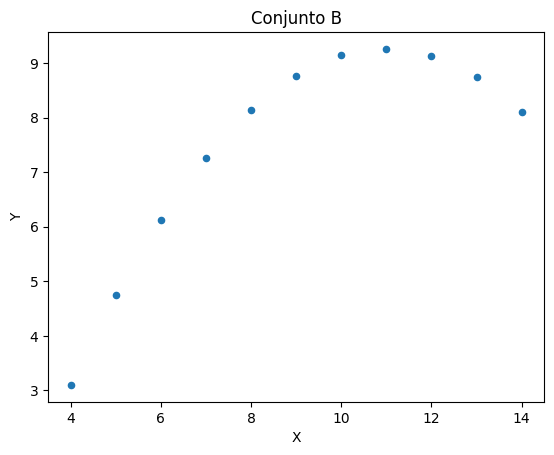

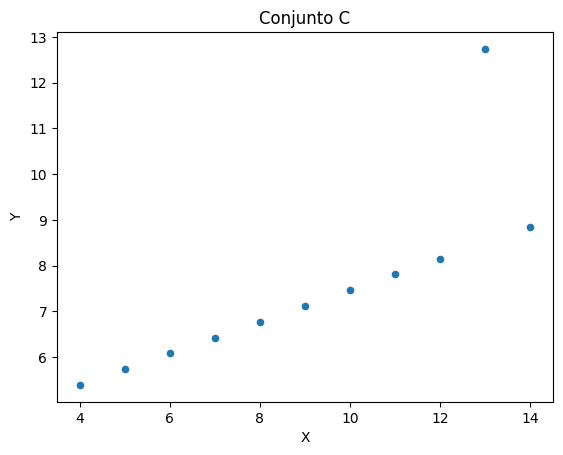

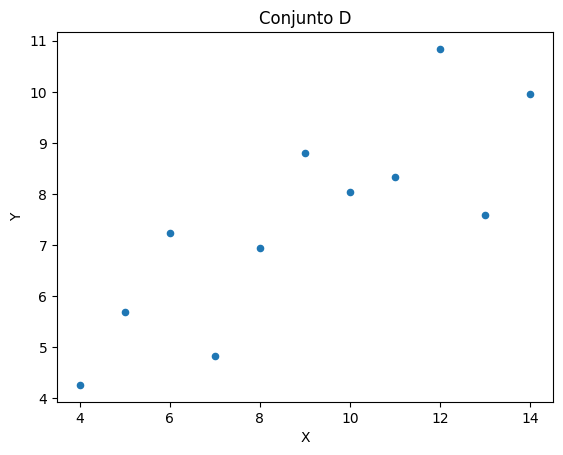

In [125]:
for name, group in df.groupby('Set'):
    group.plot.scatter(x='X', y='Y', title=f"Conjunto {name}")

El conjunto A muestra una concentración de puntos con un outlier que domina la relación, el conjunto B presenta una relación no lineal de tipo curvo, el conjunto C evidencia una tendencia lineal afectada por un solo valor atípico, y el conjunto D muestra una distribución más dispersa donde algunos puntos influyen fuertemente en la correlación. 

Así, básicamente la idea del ejercicio es ver que el análisis basado únicamente en métricas puede ser engañoso, y que la visualización es fundamental para comprender la verdadera naturaleza de los datos.

Si quieren revisar más de enumerate, que puede ser de utilidad, revisen https://www.geeksforgeeks.org/python/enumerate-in-python/

## Imputación de datos

#### Repita los pasos anteriores, esta vez descartando aleatoriamente el 10% de los datos de cada conjunto, e imputando sus valores utilizando la media de cada coordenada. Comente sobre las diferencias en los resultados

In [126]:
import numpy as np

np.random.seed(42) # para reproducibilidad

def eliminar_imputar(grupo):
    grupo = grupo.copy()
    
    n = int(len(grupo) * 0.1)
    idx = np.random.choice(grupo.index, size=n, replace=False)
    
    grupo.loc[idx, ["X", "Y"]] = np.nan
    
    grupo["X"] = grupo["X"].fillna(grupo["X"].mean())
    grupo["Y"] = grupo["Y"].fillna(grupo["Y"].mean())
    
    return grupo

In [127]:
df_imputado = df.groupby("Set")[["X", "Y"]].apply(eliminar_imputar)
df_imputado = df_imputado.reset_index()

In [128]:
metricas_df_imputado = df_imputado.groupby("Set")[["X", "Y"]].apply(metricas)
metricas_df_imputado

,media_X,media_Y,std_X,std_Y,max_X,min_X,max_Y,min_Y,correlacion,kurtosis_X,kurtosis_Y
Set,,,,,,,,,,,
A,9.1,7.547,3.300000,2.024816,19.0,8.0,12.50,5.25,0.815383,10.703704,3.032425
B,8.9,7.337,3.300000,1.957575,14.0,4.0,9.26,3.10,0.823483,-1.131823,0.861373
C,9.3,7.642,3.163858,1.975048,14.0,4.0,12.74,5.39,0.804702,-0.692308,4.502910
D,9.1,7.556,3.300000,2.023335,14.0,4.0,10.84,4.26,0.814796,-1.131823,-0.457921


In [129]:
comparacion = metricas_df - metricas_df_imputado
comparacion

,media_X,media_Y,std_X,std_Y,max_X,min_X,max_Y,min_Y,correlacion,kurtosis_X,kurtosis_Y
Set,,,,,,,,,,,
A,-0.1,-0.046091,0.016625,0.005762,0.0,0.0,0.0,0.0,0.001139,0.296296,0.118890
B,0.1,0.163909,0.016625,0.074081,0.0,0.0,0.0,0.0,-0.007247,-0.068177,-0.015250
C,-0.3,-0.142000,0.152766,0.055375,0.0,0.0,0.0,0.0,0.011585,-0.507692,-0.118821
D,-0.1,-0.055091,0.016625,0.008233,0.0,0.0,0.0,0.0,0.001624,-0.068177,-0.076977


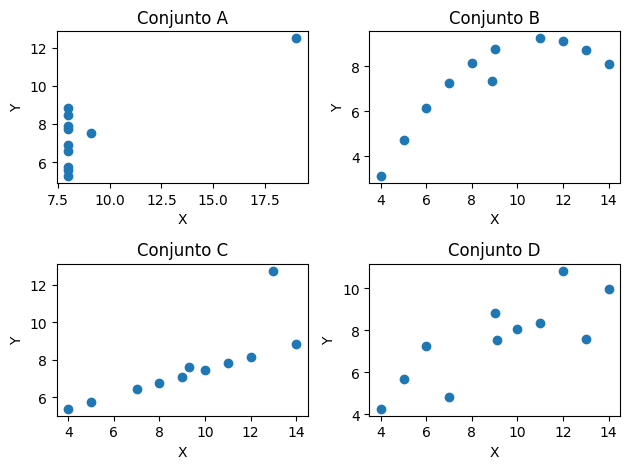

In [130]:
sets = df_imputado["Set"].unique()

for i, s in enumerate(sets):
    
    plt.subplot(2, 2, i + 1)
    subset = df_imputado[df_imputado["Set"] == s]
    
    plt.scatter(subset["X"], subset["Y"])
    plt.title(f"Conjunto {s}")
    plt.xlabel("X")
    plt.ylabel("Y")

plt.tight_layout()
plt.show()

Se observa que la media se mantiene prácticamente constante, lo cual es esperable dado que los valores faltantes fueron reemplazados por el promedio. La desviación estándar presenta ligeras disminuciones, indicando una reducción en la variabilidad de los datos. La correlación entre X e Y muestra cambios mínimos, manteniéndose relativamente estable. Sin embargo, la kurtosis evidencia variaciones más notorias, lo que sugiere cambios en la forma de la distribución. 

Así, estos resultados indican que la imputación con la media tiende a suavizar los datos, reduciendo la dispersión y pudiendo "ocultar" características relevantes como outliers o patrones estructurales.